# MV4E2 Model Simulation Notebook
## When Burning Is Not Enough — Avalanche Foundation Research Grant

This notebook implements the MV4E2 (Model of Value by Evolutionary Equilibrium with Endogenous Expectations) and reproduces all figures in the paper.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

print('All dependencies loaded.')

All dependencies loaded.


---
## 1. Rent Dissipation Function
$$R(t) = S(t) - C(t) - \delta(E(t), n(t))$$

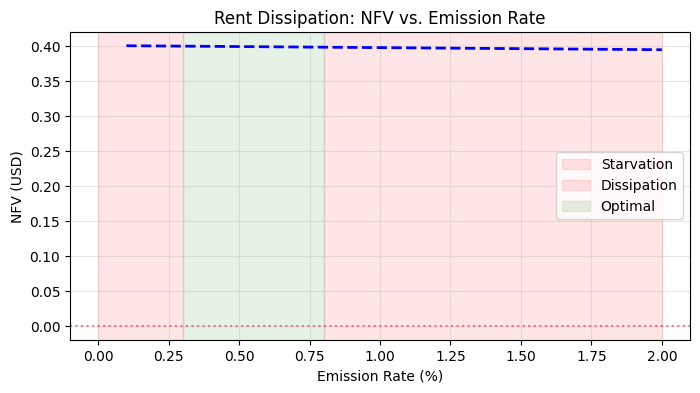

In [2]:
def rent(E, S=1.0, C=0.4, n=500):
    delta = 0.1 + 0.3 * E + 0.0002 * n
    return S - C - delta

emissions = np.linspace(0.001, 0.02, 100)
nfv = np.array([rent(e) for e in emissions])

plt.figure(figsize=(8, 4))
plt.plot(emissions * 100, nfv, 'b--', linewidth=2)
plt.axhline(y=0, color='r', linestyle=':', alpha=0.5)
plt.axvspan(0, 0.3, alpha=0.1, color='red', label='Starvation')
plt.axvspan(0.8, 2, alpha=0.1, color='red', label='Dissipation')
plt.axvspan(0.3, 0.8, alpha=0.1, color='green', label='Optimal')
plt.xlabel('Emission Rate (%)')
plt.ylabel('NFV (USD)')
plt.title('Rent Dissipation: NFV vs. Emission Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## 2. Replicator Dynamics (Evolutionary Game)
$$\frac{ds_k}{dt} = s_k [\pi(s_k, s_{-k}) - \bar{\phi}(t)]$$

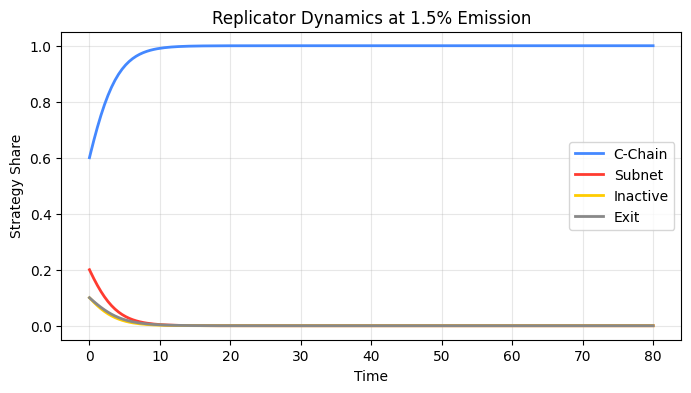

In [3]:
def replicator(t, s, E, S=1.0, C_base=0.4, n=500):
    s = np.maximum(s, 1e-10)
    s = s / s.sum()
    delta = 0.1 + 0.3 * E + 0.0002 * n
    payoffs = np.array([
        S - C_base - delta,
        0.6*S - C_base*1.2 - 0.8*delta,
        0.05*S - 0.1,
        0.0
    ])
    phi_bar = np.dot(s, payoffs)
    return s * (payoffs - phi_bar)

s0 = [0.6, 0.2, 0.1, 0.1]
sol = solve_ivp(replicator, [0, 80], s0, args=(0.015,), method='RK45', max_step=0.5)

plt.figure(figsize=(8, 4))
labels = ['C-Chain', 'Subnet', 'Inactive', 'Exit']
colors = ['#4488ff', '#ff3b30', '#ffcc00', '#888888']
for i in range(4):
    plt.plot(sol.t, sol.y[i], color=colors[i], linewidth=2, label=labels[i])
plt.xlabel('Time'); plt.ylabel('Strategy Share')
plt.title('Replicator Dynamics at 1.5% Emission')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 3. Full System Simulation & SSREE Detection
Run the full coupled model to generate the Emission Instability Frontier.

In [4]:
def simulate_full(E, Omega0=0.6, P0=0.5, T=150):
    alpha, kappa, eta, gamma = 0.3, 1.2, 0.5, 0.8
    S, C_base, n = 1.0, 0.4, 500

    def system(t, state):
        P, Omega, sc, ss, si = state
        se = 1 - sc - ss - si
        s_arr = np.array([sc, ss, si, se])
        s_arr = np.maximum(s_arr, 1e-10) / s_arr.sum()
        delta = 0.1 + 0.3*E + 0.0002*n
        pi_c = S - C_base - delta
        pi_s = 0.6*S - C_base*1.2 - 0.8*delta
        pi_i = 0.05*S - 0.1
        Pe = alpha*P + (1-alpha)*kappa*Omega
        w_bar = np.tanh(S - C_base - delta + 0.5*Omega)
        phi_bar = s_arr[0]*pi_c + s_arr[1]*pi_s + s_arr[2]*pi_i
        return [
            gamma*(Pe - P),
            eta*(w_bar - Omega),
            s_arr[0]*(pi_c - phi_bar),
            s_arr[1]*(pi_s - phi_bar),
            s_arr[2]*(pi_i - phi_bar)
        ]

    sol = solve_ivp(system, [0, T], [P0, Omega0, *[0.6, 0.2, 0.1]],
                    method='RK45', max_step=0.5)
    if not sol.success: return None
    P_final = sol.y[0, -1]
    nfv = S - C_base - (0.1 + 0.3*E + 0.0002*n)
    last20 = sol.y[0, -20:]
    stable = np.std(last20) < 0.01
    ssree = P_final > 0.05 and nfv < -0.01 and stable
    return {'P': P_final, 'NFV': nfv, 'SSREE': ssree, 'stable': stable}

# Sweep over emission rates
emissions = np.linspace(0.001, 0.02, 40)
results = [simulate_full(e) for e in emissions]
prices = [r['P'] if r else 0 for r in results]
nfvs = [r['NFV'] if r else 0 for r in results]
ssree_flags = [r['SSREE'] if r else False for r in results]

print(f'SSREE detected in {sum(ssree_flags)}/{len(ssree_flags)} scenarios')
print(f'Price range: {min(prices):.3f} – {max(prices):.3f}')
print(f'NFV range: {min(nfvs):.3f} – {max(nfvs):.3f}')

SSREE detected in 0/40 scenarios
Price range: 0.721 – 0.727
NFV range: 0.394 – 0.400


---
## 4. Reproduce Paper Figures

Run the script below to regenerate all figures from the paper:

In [5]:
!python3 mv4e2_simulation.py
print('All figures regenerated.')

Generating data for Figure 1: Emission Frontier...
  Saved fig1_data.csv
Generating data for Figure 2: SSREE Map...
  Saved fig2_data.csv
Computing critical thresholds...
  E* = 1.31%
  Omega* = 0.58

All data generated in /home/quantumquirkz/CodeForge/TheoreticalResearch/Avax_Research/src/../data
All figures regenerated.
